In [ ]:
pip install pandas matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/social_media_engagement_dataset.csv")

# Display first 5 rows
print("\nFirst 5 Records:")
print(df.head())


First 5 Records:
      Post_ID            Timestamp   Platform Content_Type  Category  Likes  \
0  POST_04552  2024-01-01 01:42:00  Instagram     Carousel  Business   8287   
1  POST_02171  2024-01-01 05:05:00   LinkedIn     Document    Health   1711   
2  POST_00210  2024-01-01 09:18:00  Instagram     Carousel      Food   1527   
3  POST_01548  2024-01-01 10:58:00   Facebook        Video    Sports    535   
4  POST_01350  2024-01-01 13:12:00  Instagram        Photo   Fitness   9706   

   Comments  Shares  Views  Saves  Follower_Count  Engagement_Rate  \
0       247      51  29502     20          223080             3.85   
1        27     247  24538    139          312647             0.63   
2       191       7   5460    359          220737             0.78   
3       178     433  68246    740          428935             0.27   
4        35     118  25782    611           64384            15.31   

   Hour_of_Day Day_of_Week  Hashtag_Count  Content_Length Sentiment  \
0            1 

In [ ]:
# Dataset Information
print("\nDataset Information:")
print(df.info())

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     5000 non-null   object 
 4   Category         5000 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   object 
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   objec

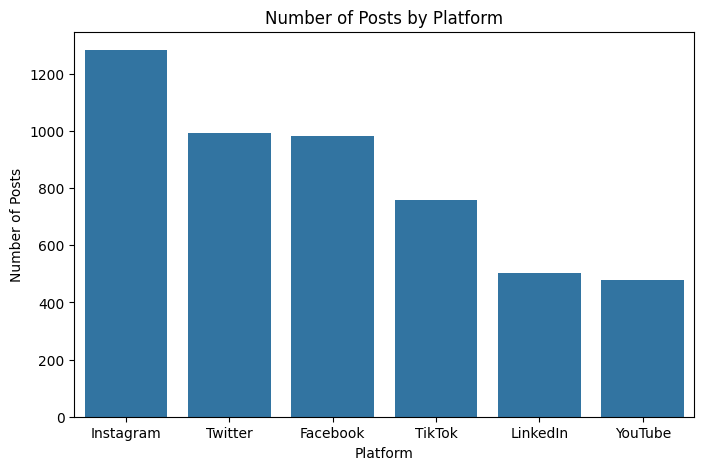

In [ ]:
# 1. Compare Posts by Platform

platform_count = df["Platform"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=platform_count.index, y=platform_count.values)
plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.show()


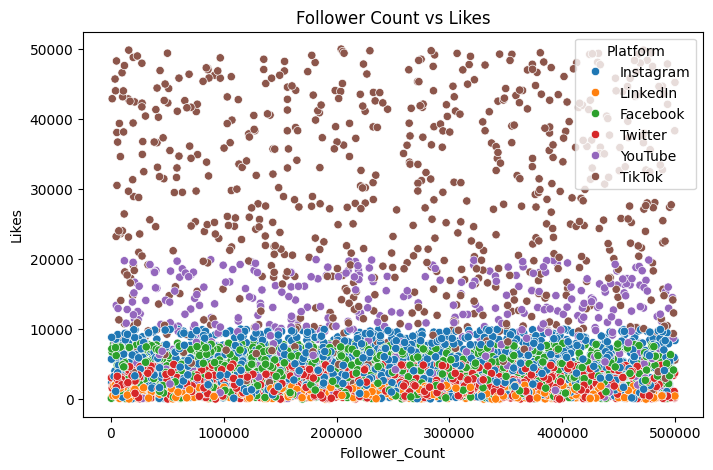

In [ ]:
# 2. Followers vs Likes
plt.figure(figsize=(8,5))
sns.scatterplot(x="Follower_Count", y="Likes", hue="Platform", data=df)
plt.title("Follower Count vs Likes")
plt.show()

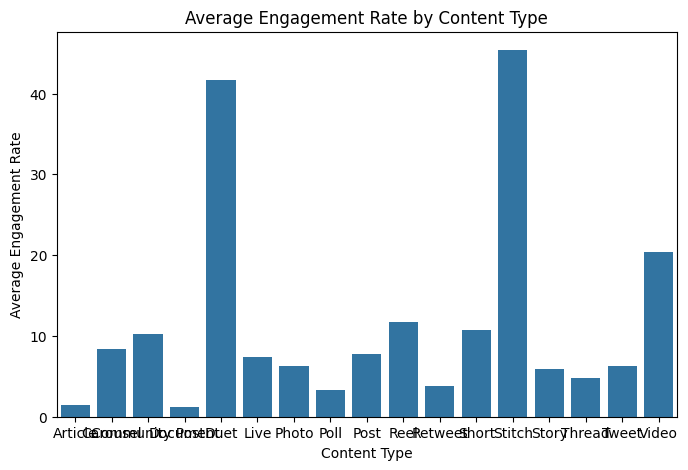

In [ ]:
# 3. Compare Engagement by Content Type

engagement = df.groupby("Content_Type")["Engagement_Rate"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=engagement.index, y=engagement.values)
plt.title("Average Engagement Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement Rate")
plt.show()

In [ ]:
# 4. Detect Viral Post Outliers

Q1 = df["Likes"].quantile(0.25)
Q3 = df["Likes"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

viral_posts = df[df["Likes"] > upper]

print("\nViral Post Outliers")
print(viral_posts)



Viral Post Outliers
         Post_ID            Timestamp Platform Content_Type   Category  Likes  \
10    POST_04605  2024-01-02 20:22:00   TikTok        Video     Travel  18977   
23    POST_04272  2024-01-04 20:52:00  YouTube         Live     Travel  19612   
34    POST_00013  2024-01-07 05:44:00   TikTok        Video    Fitness  37311   
49    POST_02509  2024-01-09 02:24:00   TikTok        Video   Business  33034   
55    POST_04525  2024-01-09 13:30:00   TikTok       Stitch  Lifestyle  46571   
...          ...                  ...      ...          ...        ...    ...   
4963  POST_01674  2025-12-27 16:25:00   TikTok       Stitch  Education  33163   
4965  POST_00632  2025-12-27 20:26:00   TikTok         Duet     Sports  49713   
4967  POST_00821  2025-12-27 22:40:00   TikTok       Stitch    Fitness  17266   
4990  POST_04448  2025-12-31 04:42:00   TikTok        Video  Education  43378   
4997  POST_03265  2025-12-31 18:37:00   TikTok       Stitch     Travel  44391   

      

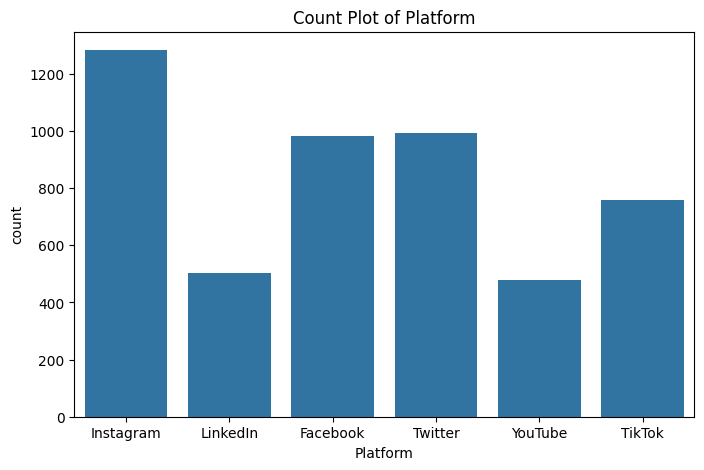

In [ ]:
# 5. Count Plot

plt.figure(figsize=(8,5))
sns.countplot(x="Platform", data=df)
plt.title("Count Plot of Platform")
plt.show()



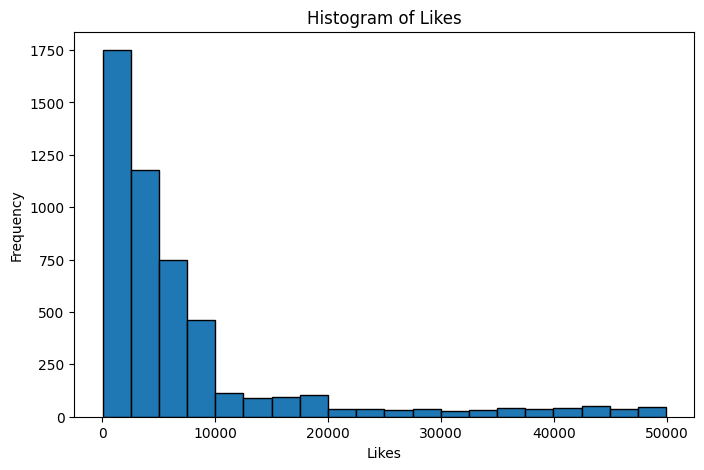

In [ ]:
#6. Histogram

plt.figure(figsize=(8,5))
plt.hist(df["Likes"], bins=20, edgecolor="black")
plt.title("Histogram of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()


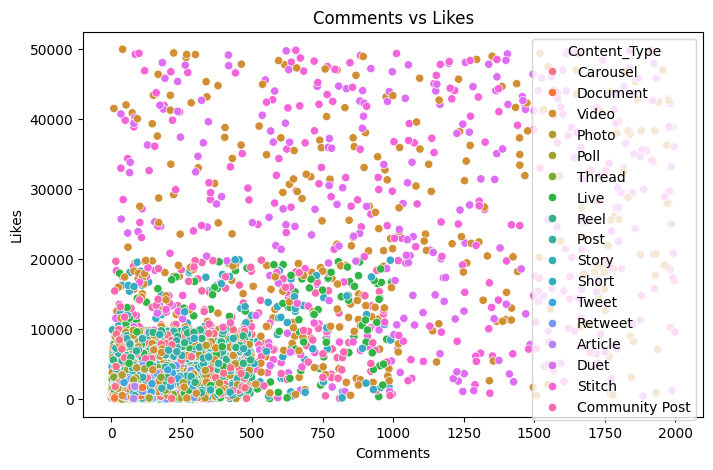

In [ ]:
# 7. Scatter Plot

plt.figure(figsize=(8,5))
sns.scatterplot(x="Comments", y="Likes", hue="Content_Type", data=df)
plt.title("Comments vs Likes")
plt.show()

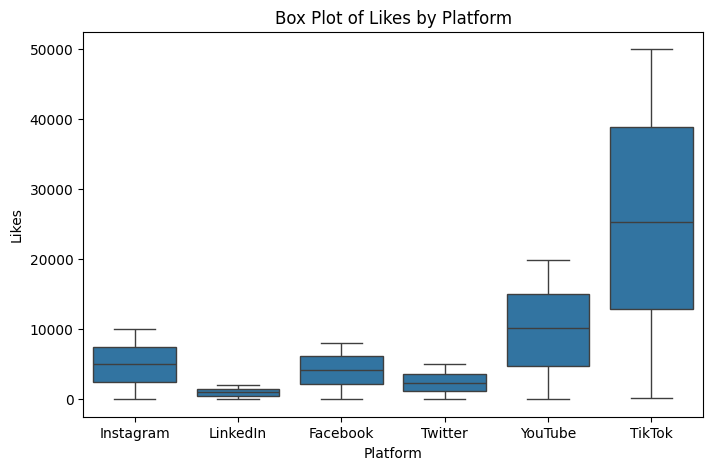

In [ ]:
#8. Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Platform", y="Likes", data=df)
plt.title("Box Plot of Likes by Platform")
plt.show()


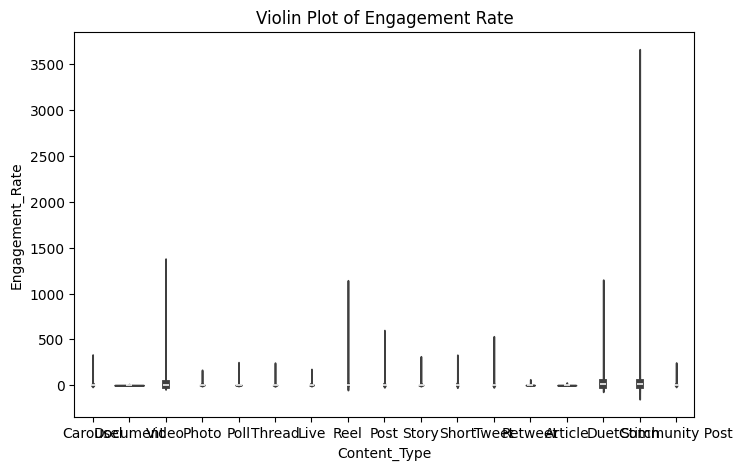

In [ ]:
# 9. Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(x="Content_Type", y="Engagement_Rate", data=df)
plt.title("Violin Plot of Engagement Rate")
plt.show()


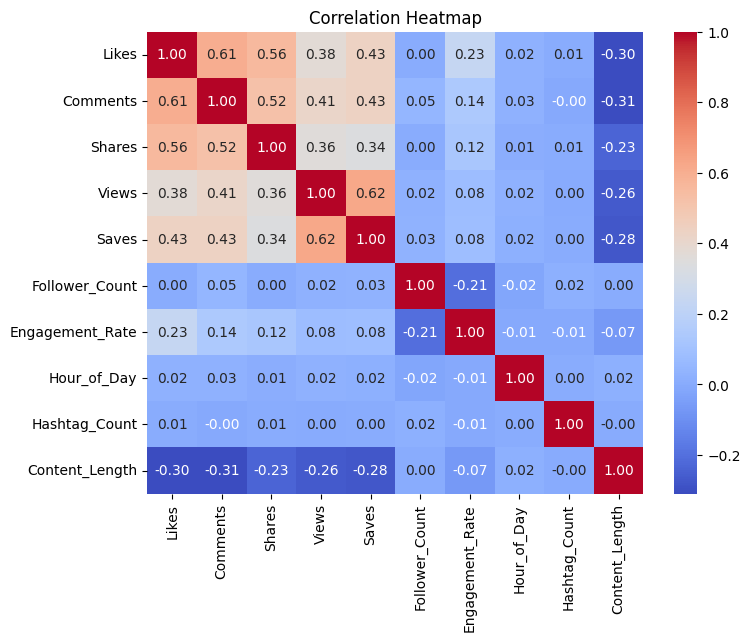

In [ ]:
# 10. Correlation Heatmap
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()